In [ ]:
from mGST.utility_functions_comparisons import get_full_mgst_parameters_from_configuration, factorize_psd_truncated, create_4q_gst_config, is_isometry, run_gds_jax
from iqm.benchmarks.compressive_gst.compressive_gst import GSTConfiguration
 
from mGST.low_level_jit import cost_function_jax_mps, gradient_all_3_and_value_jit, cost_function_numba, cost_function_jax

import jax.numpy as jnp
import jax

import numpy as np

import matplotlib.pyplot as plt

backend = "iqmfakeapollo"

%load_ext autoreload
%autoreload 2

# 4Q GST tests

In [2]:
Q4_GST = create_4q_gst_config()

K, X, E, rho, y, J, l, depth, pdim, dim_squared, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q4_GST, backend, seed=42
)

2025-02-20 11:48:13,180 - iqm.benchmarks.logging_config - INFO - Now generating 2000 random GST circuits...
2025-02-20 11:48:15,292 - iqm.benchmarks.logging_config - INFO - Will transpile all 2000 circuits according to fixed physical layout
2025-02-20 11:48:15,292 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-02-20 11:48:26,350 - iqm.benchmarks.logging_config - INFO - Submitting batch with 2000 circuits corresponding to qubits [0, 1, 3, 4]
2025-02-20 11:48:26,370 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-02-20 11:48:26,393 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-02-20 11:49:30,891:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-02-20 11:49:30,891 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': m

In [4]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)

# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)

jnp.allclose(state_psd @ state_psd.T, state), jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [25]:
initial_cost = cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)
initial_cost

Initial count: 15


Array(0.00062581, dtype=float64)

In [10]:
%timeit cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 10 the new count changed to: 3
at iteration 91 the new count changed to: 4
at iteration 242 the new count changed to: 5
at iteration 393 the new count changed to: 6
at iteration 544 the new count changed to: 7
at iteration 696 the new count changed to: 8
at iteration 848 the new count changed to: 9
at iteration 1000 the new count changed to: 10
at iteration 1166 the new count changed to: 11
at iteration 1332 the new count changed to: 12
at iteration 1499 the new count changed to: 13
at iteration 1666 the new count changed to: 14
at iteration 1833 the new count changed to: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
139 ms ± 3.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [11]:
%timeit gradient_k_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
9.31 s ± 222 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [15]:
%timeit gradient_all_3_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
Initial count: 15
10.2 s ± 248 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [18]:
10.2 * 100 /60

16.999999999999996

In [19]:
state_psd.shape, povm_psd.shape

((16, 1), (16, 16, 1))

In [21]:
povm_matrix = jnp.transpose(povm_psd, (0, 2, 1)).reshape((num_povm * 1, dim))
is_isometry(povm_matrix)

Array(True, dtype=bool)

In [22]:
jnp.array([state_psd]).shape

(1, 16, 1)

In [ ]:
# try the optimization using the update functions
kraus_opt_test_geodesic, cost_fn_history_test_geodesic = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=10, target_rel_prec=1e-3, step_size=50, optimize_step=False, use_geodesic=True)

iteration:  0
Initial count: 15
cost:  0.0006258096017386882
iteration:  1
Initial count: 15
cost:  0.0005570235375896271
iteration:  2
Initial count: 15
cost:  0.0005218107679886996
iteration:  3
Initial count: 15
cost:  0.0004995521696915633
iteration:  4
Initial count: 15
cost:  0.000483893714599985
iteration:  5
Initial count: 15
cost:  0.00047221126572836704
iteration:  6
Initial count: 15
cost:  0.0004631403586667719
iteration:  7
Initial count: 15
cost:  0.0004558723352696219
iteration:  8
Initial count: 15
cost:  0.0004498929626533011
iteration:  9
Initial count: 15
cost:  0.0004448604351059445


In [33]:
povm_psd.shape

(16, 16, 1)

In [ ]:
# try the optimization using the update functions
kraus_opt, povm_opt, sate_opt, cost_fn_history_all_opt = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=10, target_rel_prec=1e-3, step_size=50, optimize_step=False, use_geodesic=True)

iteration:  0
Initial count: 15
cost:  0.0006258096017386882
iteration:  1
Initial count: 15
cost:  0.0005511199496883764
iteration:  2
Initial count: 15
cost:  0.0005168035552703937
iteration:  3
Initial count: 15
cost:  0.0004939840837651837
iteration:  4
Initial count: 15
cost:  0.0004777105352154946
iteration:  5
Initial count: 15
cost:  0.0004654745683528412
iteration:  6
Initial count: 15
cost:  0.0004558426451289006
iteration:  7
Initial count: 15
cost:  0.0004479469187826356
iteration:  8
Initial count: 15
cost:  0.0004412362536530275
iteration:  9
Initial count: 15
cost:  0.0004353474921169347


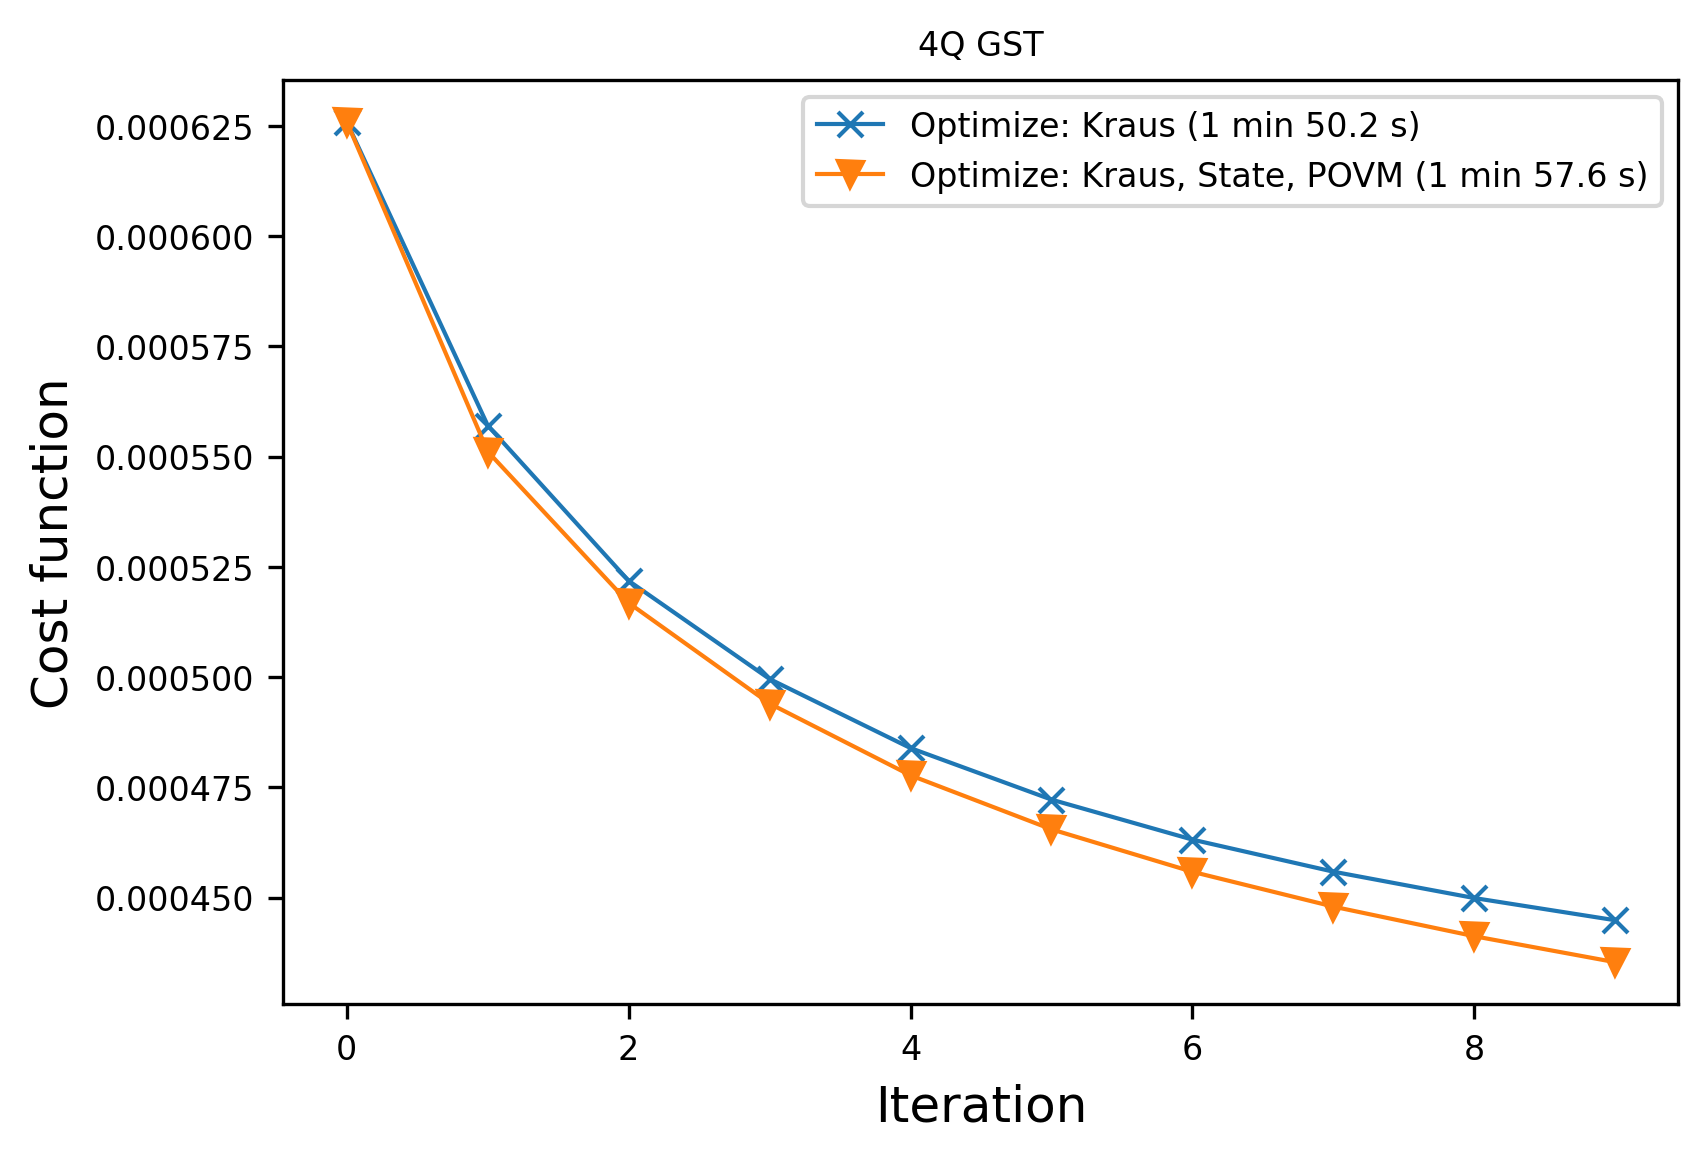

In [36]:
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(len(cost_fn_history_test_geodesic)), cost_fn_history_test_geodesic, marker="x", linestyle="-", linewidth=1, markersize=6, label="Optimize: Kraus (1 min 50.2 s)")
plt.plot(range(len(cost_fn_history_all_opt)), cost_fn_history_all_opt, marker="v", linestyle="-", linewidth=1, markersize=6, label="Optimize: Kraus, State, POVM (1 min 57.6 s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"4Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

# Compare against previously implemented methods in mGST for 2Q GST

In [2]:
from mGST.algorithm import run_mGST

In [4]:
# first let's calculate the cost function using numba
# Euclidean Gradient
Q2_GST = GSTConfiguration(
    qubit_layouts=[[0, 1]],
    gate_set="2QXYCZ",
    num_circuits=800,
    shots=1000,
    rank=4,
)

K, X, E, rho, y, J, l, d, pdim, r, n_povm, bsize, meas_samples, n, nt, rK = get_full_mgst_parameters_from_configuration(
    Q2_GST, backend, seed=42
)

2025-03-03 17:49:55,461 - iqm.benchmarks.logging_config - INFO - Now generating 800 random GST circuits...
2025-03-03 17:49:56,112 - iqm.benchmarks.logging_config - INFO - Will transpile all 800 circuits according to fixed physical layout
2025-03-03 17:49:56,113 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2025-03-03 17:49:58,094 - iqm.benchmarks.logging_config - INFO - Submitting batch with 800 circuits corresponding to qubits [0, 1]
2025-03-03 17:49:58,100 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2025-03-03 17:49:58,131 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
INFO:2025-03-03 17:50:04,077:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-03-03 17:50:04,077 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'ja

In [5]:
E.shape, rho.shape, K.shape

((4, 16), (16,), (5, 4, 4, 4))

In [ ]:
K_np = np.array(K)
E_np = np.array(E)
rho_np = np.array(rho)
y_np = np.array(y)
X_np = np.array(X)

In [7]:
# creating the parameters needed for the jax version
num_povm = E.shape[0]
dim = int(jnp.sqrt(E.shape[1]))

povm_tensor = jnp.reshape(E, shape=(num_povm, dim, dim))
state = jnp.reshape(rho, shape=(dim, dim))

indices_list = [indices[indices != -1] for indices in J]

kraus_tensor = K
prob_matrix = y

state_psd = factorize_psd_truncated(psd=state, max_rank=1)
povm_psd  = factorize_psd_truncated(psd=povm_tensor, max_rank=1)

jnp.allclose(state_psd @ state_psd.T, state), jnp.allclose(povm_psd @ povm_psd.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [9]:
cost_function_numba(K_np, E_np, rho_np, J, y_np)

0.0018322287375307235

In [11]:
cost_function_jax(X, E, rho, indices_list, y)

Array(0.00183223, dtype=float64)

In [75]:
kraus_updated_2q_mgst, x_kraus_updated_2q_mgst, povm_updated_2q_mgst, state_updated_2q_mgst, cost_fn_history_2q_mgst = run_mGST(
    y_np, indices_list, 0, d, r, rK, n_povm, bsize, meas_samples,
    init = [K_np, E_np, rho_np],
    method = "GD",
    max_iter=100,
    target_rel_prec=1e-4,
)

Starting mGST optimization...
100%|██████████| 70/70 [10:50<00:00,  9.29s/it]
	 Convergence criterion satisfied
	 Final objective 0.00015345610453170925 in time 650.66s


In [10]:
# jax version to compile first
cost_value_jax_2q_init = cost_function_jax_mps(kraus_tensor, povm_tensor, state_psd, indices_list, prob_matrix, jit=True)
cost_value_jax_2q_init

Initial count: 0
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 6 the new count changed to: 3
at iteration 31 the new count changed to: 4
at iteration 92 the new count changed to: 5
at iteration 153 the new count changed to: 6
at iteration 214 the new count changed to: 7
at iteration 276 the new count changed to: 8
at iteration 338 the new count changed to: 9
at iteration 400 the new count changed to: 10
at iteration 466 the new count changed to: 11
at iteration 532 the new count changed to: 12
at iteration 599 the new count changed to: 13
at iteration 666 the new count changed to: 14
at iteration 733 the new count changed to: 15


Array(0.00183223, dtype=float64)

In [ ]:
kraus_updated_2q_jax, povm_updated_2q_jax, state_updated_2q_jax, cost_fn_history_2q_jax = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=False)

iteration:  0
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
optimized step size:  [4.56103517]
cost:  0.0018090037849567786
iteration:  1
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
optimized step size:  [5.27343751]
cost:  0.0012822566212795522
iteration:  2
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
In

In [ ]:
kraus_updated_2q_opt_step_all, povm_updated_2q_opt_step_all, state_updated_2q_opt_step_all, cost_fn_history_2q_opt_step_all = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=False)

iteration:  0
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
optimized step size:  [3.99121095]
cost:  0.0018090037849567786
iteration:  1
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
optimized step size:  [6.20019532]
cost:  0.001271191118216871
iteration:  2
Initial count: 31
Initial count: 31
Initial count: 31
Initial count: 31
Ini

In [86]:
len(cost_fn_history_2q_opt_step_all)

173

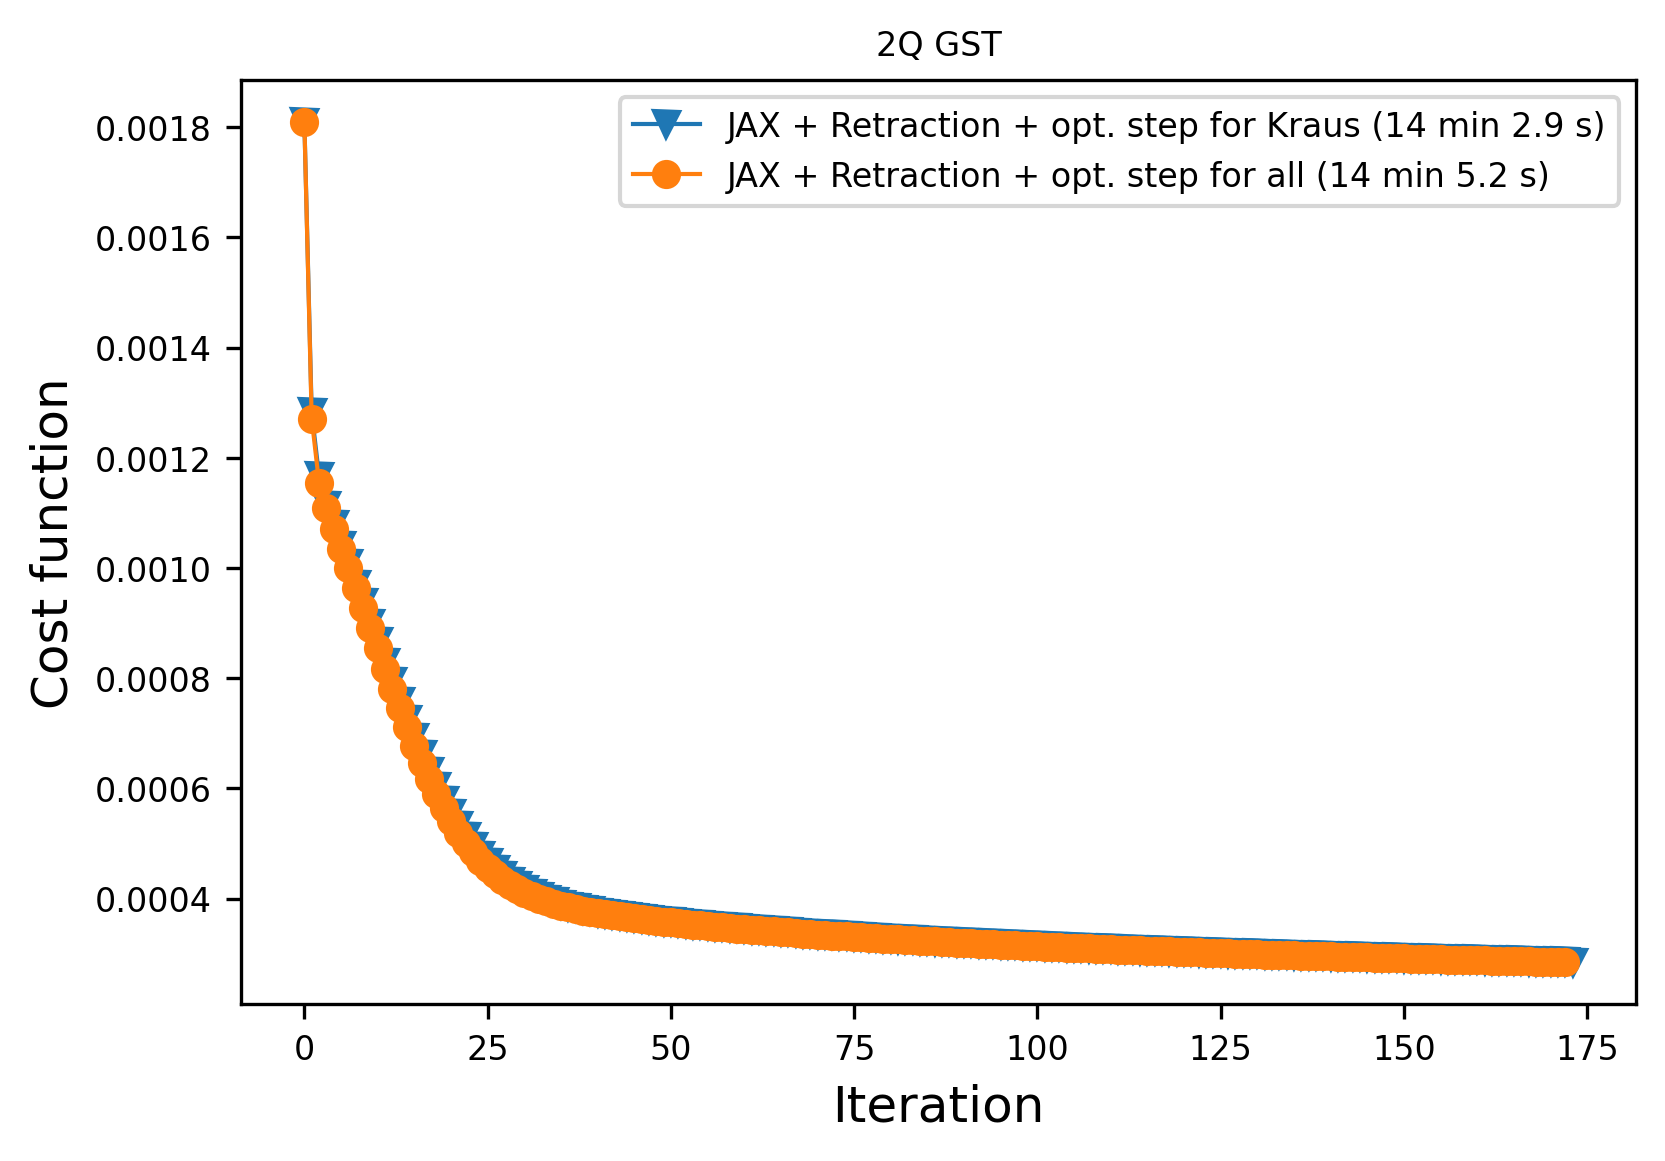

In [88]:
plt.figure(figsize=(6, 4), dpi=300)
# plt.plot(range(len(cost_fn_history_2q_mgst)), cost_fn_history_2q_mgst, marker="x", linestyle="-", linewidth=1, markersize=6, label="mGST (10 min 50.7 s)")
plt.plot(range(len(cost_fn_history_2q_jax)), cost_fn_history_2q_jax, marker="v", linestyle="-", linewidth=1, markersize=6, label="JAX + Retraction + opt. step for Kraus (14 min 2.9 s)")
plt.plot(range(len(cost_fn_history_2q_opt_step_all)), cost_fn_history_2q_opt_step_all, marker="o", linestyle="-", linewidth=1, markersize=6, label="JAX + Retraction + opt. step for all (14 min 5.2 s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

In [106]:
povm_psd.shape

(4, 4, 1)

In [97]:
test_rank = 3
test_povm = factorize_psd_truncated(psd=povm_tensor, max_rank=test_rank)
test_matrix = jnp.reshape(test_povm, (num_povm*test_rank, dim))
is_isometry(test_matrix), jnp.allclose(test_povm @ test_povm.conj().transpose(0, 2, 1), povm_tensor)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [105]:
test_matrix_2 = jnp.reshape(test_povm.transpose((0, 2, 1)), (num_povm*test_rank, dim))
jnp.allclose(test_matrix, test_matrix_2), is_isometry(test_matrix_2)

(Array(False, dtype=bool), Array(True, dtype=bool))

In [108]:
# checking that the code reverses what the other one does
from mGST.utility_functions_comparisons import euclidean_gradients_to_stiefel

In [ ]:
# POVM tensor to stiefel
previous_shape = povm_psd.shape[0], povm_psd.shape[2], povm_psd.shape[1]
_, povm_isometry =  euclidean_gradients_to_stiefel(gradient_tensor=povm_psd, operator_tensor=povm_psd, operator_type="povm")

new_povm_psd = jnp.reshape(povm_isometry, shape=previous_shape)
new_povm_psd = jnp.transpose(new_povm_psd, axes=(0, 2, 1))

jnp.allclose(new_povm_psd, povm_psd), povm_psd.shape, new_povm_psd.shape

(Array(True, dtype=bool), (4, 4, 1), (4, 4, 1))

In [ ]:
kraus_updated_2q_opt_step_all_v2, povm_updated_2q_opt_step_all_v2, state_updated_2q_opt_step_all_v2, cost_fn_history_2q_opt_step_all_v2 = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=False)

iteration:  0
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
optimized step size:  [3.99121095]
cost:  0.0018090037849567786
iteration:  1
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
optimized step size:  [6.20019532]
cost:  0.001271191118216871
iteration:  2
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Ini

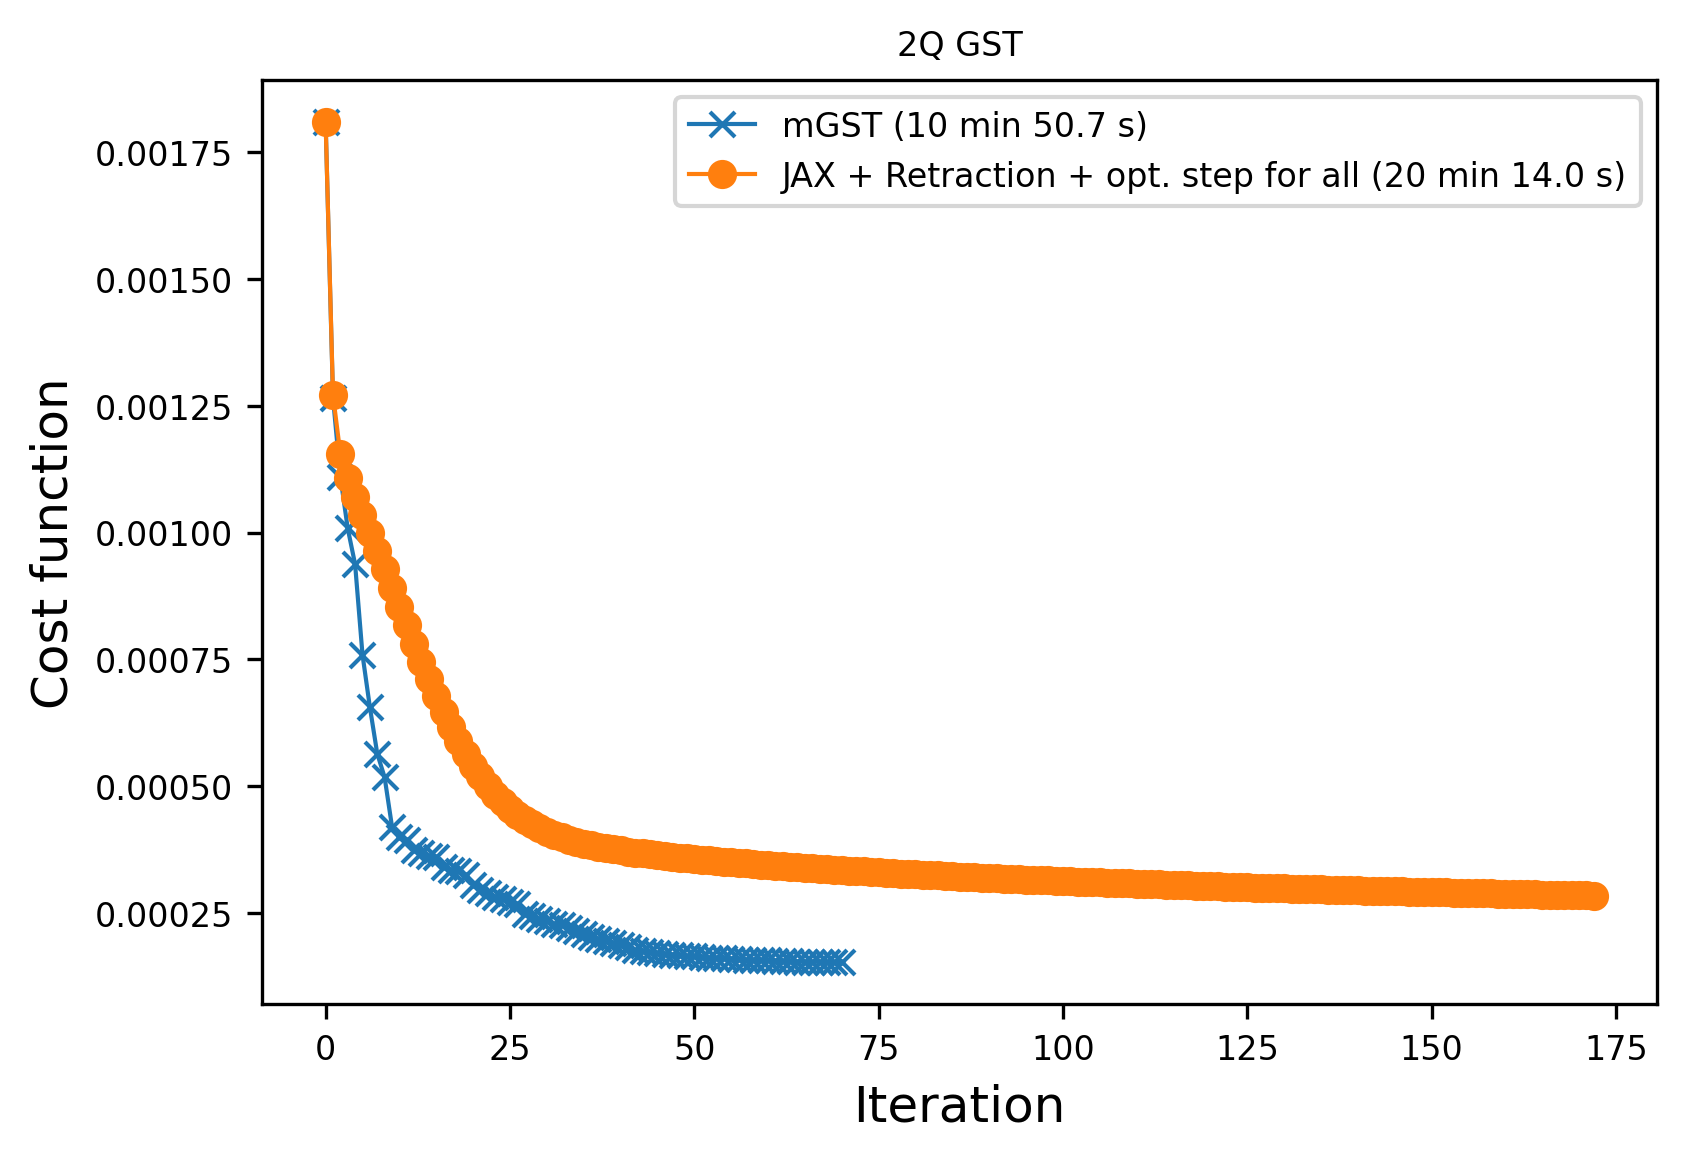

In [113]:
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(range(len(cost_fn_history_2q_mgst)), cost_fn_history_2q_mgst, marker="x", linestyle="-", linewidth=1, markersize=6, label="mGST (10 min 50.7 s)")
plt.plot(range(len(cost_fn_history_2q_opt_step_all_v2)), cost_fn_history_2q_opt_step_all_v2, marker="o", linestyle="-", linewidth=1, markersize=6, label="JAX + Retraction + opt. step for all (20 min 14.0 s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.legend()

In [ ]:
kraus_updated_2q_opt_step_all_v3, povm_updated_2q_opt_step_all_v3, state_updated_2q_opt_step_all_v3, cost_fn_history_2q_opt_step_all_v3 = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=False)

iteration:  0
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
optimized step size: [4.50452873 0.22929409 1.7209084 ]
cost:  0.0018090037849567786
iteration:  1
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
Initial count: 46
optimized step size: [ 7.17731129 -1.38028353  5.74654314]
cost:  0.0012513510194515434
iteration:  2
Initial count: 46
Initial cou

In [ ]:
kraus_updated_2q_opt_step_all_v3_geodesic, povm_updated_2q_opt_step_all_v3_geodesic, state_updated_2q_opt_step_all_v3_geodesic, cost_fn_history_2q_opt_step_all_v3_geodesic = run_gds_jax(kraus_tensor=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=y, max_iter=250, target_rel_prec=1e-3, step_size=1e-8, optimize_step=True, use_geodesic=True)

iteration:  0
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
optimized step size: [4.50477051 0.22941475 1.72051145]
cost:  0.0018090037849567786
iteration:  1
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
optimized step size: [ 7.17737932 -1.38308396  5.75179896]
cost:  0.0012513111763184986
iteration:  2
Initial count: 30
Initial cou

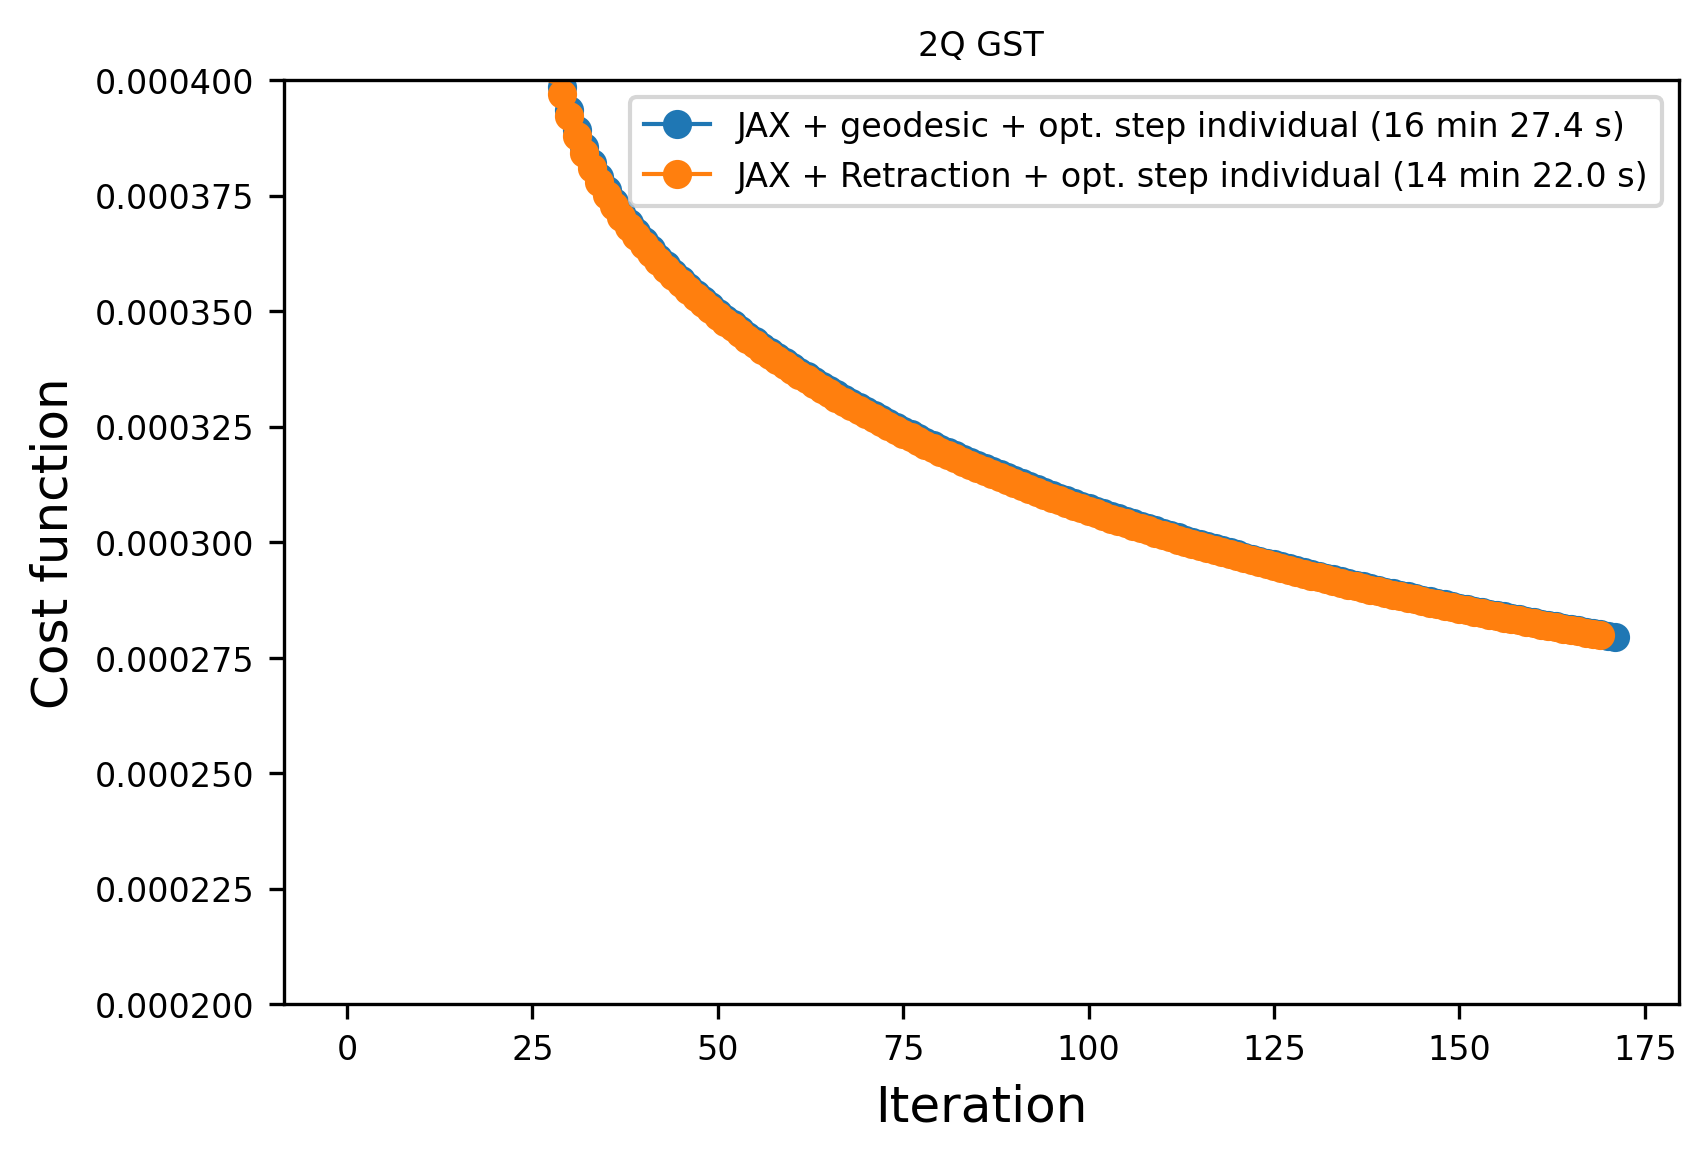

In [653]:
plt.figure(figsize=(6, 4), dpi=300)
# plt.plot(range(len(cost_fn_history_2q_mgst)), cost_fn_history_2q_mgst, "-x", linewidth=1, markersize=6, label="mGST (10 min 50.7 s)")
# plt.plot(range(len(cost_fn_history_2q_opt_step_all_v2)), cost_fn_history_2q_opt_step_all_v2, marker="o", linestyle="-", linewidth=1, markersize=6, label="JAX + Retraction + opt. step for all (20 min 14.0 s)")
plt.plot(range(len(cost_fn_history_2q_opt_step_all_v3_geodesic)), cost_fn_history_2q_opt_step_all_v3_geodesic, marker="o", linestyle="-", linewidth=1, markersize=6, label="JAX + geodesic + opt. step individual (16 min 27.4 s)")
plt.plot(range(len(cost_fn_history_2q_opt_step_all_v3)), cost_fn_history_2q_opt_step_all_v3, "-o", linewidth=1, markersize=6, label="JAX + Retraction + opt. step individual (14 min 22.0 s)")
plt.xlabel("Iteration", fontsize=12)
plt.title(r"2Q GST")
plt.ylabel("Cost function", fontsize=12)
plt.ylim(0.0002, 0.0004)
plt.legend()

# Testing the gradients

In [12]:
# test the gradients again
from mGST.low_level_jit import ddA_derivs, ddB_derivs, dK

A = np.array(povm_psd)
B = np.array(state_psd)

In [13]:
state_psd_full_rank = factorize_psd_truncated(psd=state, max_rank=dim)
povm_psd_full_rank = factorize_psd_truncated(psd=povm_tensor, max_rank=dim)

B_full_rank = np.array(state_psd_full_rank)
A_full_rank = np.array(povm_psd_full_rank)

In [36]:
povm_tensor.shape

(4, 4, 4)

In [39]:
povm_psd_test = factorize_psd_truncated(psd=povm_tensor, max_rank=2) # num_povm, dim, rank
povm_psd_test = povm_psd_test.transpose((0, 2, 1)) # num_povm x rank x dim
jnp.allclose(povm_psd_test.transpose((0, 2, 1)).conj() @ povm_psd_test, povm_tensor)

Array(True, dtype=bool)

In [14]:
A_numba = np.array([np.linalg.cholesky(E[k].reshape(pdim, pdim) + 1e-14 * np.eye(pdim)).T.conj() for k in range(n_povm)])
B_numba = np.linalg.cholesky(rho.reshape(pdim, pdim) + 1e-14 * np.eye(pdim))

A_numba.shape, B_numba.shape

((4, 4, 4), (4, 4))

In [15]:
gradient_kraus_numba = dK(X_np, K_np, E_np, rho_np, J, y_np, d, r, rK)

In [16]:
gradient_povm_numba, *_ = ddA_derivs(X_np, A_numba, B_numba, J, y_np, r, pdim, n_povm)

In [17]:
gradient_povm_numba_no_parallel, *_ = ddA_derivs(X_np, A_numba, B_numba, J, y_np, r, pdim, n_povm)

In [18]:
jnp.allclose(gradient_povm_numba, gradient_povm_numba_no_parallel)

Array(True, dtype=bool)

In [204]:
gradient_povm_numba_test, *_ = ddA_derivs(X_np, A_full_rank, B_full_rank, J, y_np, r, pdim, n_povm)

In [460]:
jnp.allclose(gradient_povm_numba_test, gradient_povm_numba), jnp.allclose(gradient_povm_numba_test, gradient_povm_numba_no_parallel)

(Array(False, dtype=bool), Array(False, dtype=bool))

In [461]:
gradient_povm_numba_test_no_parallel, *_ = ddA_derivs(X_np, A_full_rank, B_full_rank, J, y_np, r, pdim, n_povm)

In [462]:
jnp.allclose(gradient_povm_numba_test_no_parallel, gradient_povm_numba_no_parallel)

Array(False, dtype=bool)

In [25]:
gradient_state_numba, *_ = ddB_derivs(X_np, A_numba, B_numba, J, y_np, r, pdim)

In [19]:
value_test, gradient_all_jax = gradient_all_3_and_value_jit(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix)

Initial count: 15


In [21]:
value_test_full_rank, gradient_all_jax_full_rank = gradient_all_3_and_value_jit(kraus_tensor, povm_psd_full_rank, state_psd_full_rank, indices_list, prob_matrix)

Initial count: 15


In [194]:
jnp.allclose(value_test, value_test_full_rank)

Array(True, dtype=bool)

In [22]:
gradient_kraus_jax_full_rank, gradient_povm_jax_full_rank, gradient_state_jax_full_rank = gradient_all_jax_full_rank
[gradient.shape for gradient in gradient_all_jax_full_rank]

[(5, 4, 4, 4), (4, 4, 4), (4, 4)]

In [26]:
gradient_kraus_jax, gradient_povm_jax, gradient_state_jax = gradient_all_jax
gradient_povm_jax.shape, gradient_povm_numba.shape, gradient_state_jax.shape, gradient_state_numba.shape

((4, 4, 1), (4, 4, 4), (4, 1), (4, 4))

In [241]:
jnp.allclose(gradient_kraus_numba, gradient_kraus_jax/2)

Array(True, dtype=bool)

In [190]:
jnp.allclose(gradient_state_numba[:,0], gradient_state_jax[:,0]/2)

Array(True, dtype=bool)

In [196]:
jnp.allclose(gradient_state_numba, gradient_state_jax_full_rank/2)

Array(True, dtype=bool)

In [220]:
jnp.allclose(gradient_povm_numba_test, gradient_povm_jax_full_rank.transpose(0,2,1)/2)

Array(False, dtype=bool)

In [464]:
jnp.allclose(gradient_povm_numba_test_no_parallel, gradient_povm_jax_full_rank.transpose(0,2,1)/2)

Array(False, dtype=bool)

In [470]:
for gradient_numba, gradient_jax in zip(gradient_povm_numba_test_no_parallel, gradient_povm_jax_full_rank):
    print(jnp.linalg.norm(gradient_numba - gradient_jax.T/2))

1.8237370506727717e-05
0.025513684508569123
0.025709785913864545
0.033111836123720234


In [478]:
for gradient_numba, gradient_jax in zip(gradient_povm_numba_test, gradient_povm_jax_full_rank.transpose(0,2,1)):
    print(jnp.linalg.norm(gradient_numba - gradient_jax/2))

1.2568051128417139e-06
0.02551192101291188
0.02571734301461807
0.03324573757524171


In [501]:
idx = 1
povm_idx = 0
gradient_povm_numba_test[povm_idx,:,:]

array([[ 3.06790198e-03-8.20308817e-20j,  7.40714013e-05+3.71598070e-04j,
         4.34470877e-04-7.02309962e-04j, -2.10049477e-04-2.46020387e-04j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j]])

In [472]:
gradient_povm_jax_full_rank[povm_idx,:,:].T/2

Array([[ 3.06768270e-03+2.43474267e-36j,  7.41653200e-05+3.70641348e-04j,
         4.34427171e-04-7.02361033e-04j, -2.09943769e-04-2.46789572e-04j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j]],      dtype=complex128)

In [474]:
gradient_povm_numba[povm_idx,:,:]

array([[ 3.06373970e-03-8.31715967e-20j,  7.90319372e-05+3.70153888e-04j,
         4.29714521e-04-7.02068028e-04j, -2.06883971e-04-2.47049968e-04j],
       [ 7.86516030e-12-3.70189438e-11j, -1.31899260e-10-2.23284344e-27j,
        -1.91133023e-11-2.35543363e-12j,  9.83109452e-12+6.41087141e-12j],
       [ 4.30104631e-11+7.02047427e-11j, -1.91133023e-11+2.35543363e-12j,
        -1.20889580e-10-1.96428936e-26j, -1.13229603e-11+1.29443522e-11j],
       [-2.06197442e-11+2.47084179e-11j,  9.77756413e-12-6.41657004e-12j,
        -1.12796680e-11-1.22917655e-11j, -8.42020814e-11-9.85918054e-27j]])

In [477]:
gradient_povm_numba_no_parallel[povm_idx,:,:]

array([[ 3.05964874e-03-8.14244588e-20j,  7.96657737e-05+3.71221997e-04j,
         4.43662906e-04-6.85677290e-04j, -2.01447029e-04-2.45936798e-04j],
       [ 7.95507547e-12-3.71700980e-11j, -1.29010947e-10-3.77873112e-28j,
        -1.91328085e-11-2.34904652e-12j,  1.06581072e-11+5.05461004e-12j],
       [ 4.36114318e-11+7.02009899e-11j, -1.97674429e-11+2.37299280e-12j,
        -1.20912494e-10-1.78146893e-26j, -1.13436863e-11+1.22861726e-11j],
       [-2.05366650e-11+2.46376741e-11j,  9.82399780e-12-5.03149541e-12j,
        -1.13974402e-11-1.22313432e-11j, -8.23404769e-11-7.53529155e-27j]])

In [476]:
gradient_povm_numba_test_no_parallel[povm_idx,:,:]

array([[ 3.07612565e-03-8.18537143e-20j,  7.52844215e-05+3.60143947e-04j,
         4.25001958e-04-7.01996204e-04j, -2.08301848e-04-2.54418903e-04j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j]])

## POVM gradient

In [628]:
# testing the gradient from 
f_povm_jax = lambda povm_psd: cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)
f_povm_numba = lambda povm_full: cost_function_numba(K_np, povm_full, rho_np, J, y_np)

def cost_alpha(alpha, initial_povm, jax:bool = True):
    "cost function f(povm + alpha*gradient) as a function of alpha"
    if jax:
        povm_alpha = initial_povm +  alpha * gradient_povm_jax.conj()/2
        return f_povm_jax(povm_alpha)
    povm_alpha = initial_povm + alpha * gradient_povm_numba.conj()
    
    povm_full = np.array([(povm.T.conj() @ povm).reshape(-1) for povm in povm_alpha])
    return f_povm_numba(povm_full)

def tensor_inner_product_euclidean(tensor:jnp.array):
    "Euclidean norm of a tensor of rank 3"
    return jnp.real(jnp.einsum("ijk,ijk", tensor, tensor.conj()))

def linear_approx(alpha, initial_povm, jax:bool = True):
    "Linear approximation of cost_alpha around k"
    if jax:
        return f_povm_jax(initial_povm) + 2 * alpha * tensor_inner_product_euclidean(gradient_povm_jax/2)
    povm_full = np.array([(povm.T.conj() @ povm).reshape(-1) for povm in initial_povm])
    return f_povm_numba(povm_full) + 2 * alpha * tensor_inner_product_euclidean(gradient_povm_numba)

In [629]:
alphas = np.arange(-5, 5, 0.05)
function_value_povm_numba = [cost_alpha(alpha, A_numba, jax=False) for alpha in alphas]

In [630]:
function_value_povm_jax = [cost_alpha(alpha, povm_psd, jax=True) for alpha in alphas]

Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial co

In [495]:
linear_approx_povm_numba = [linear_approx(alpha, A_numba, jax=False) for alpha in alphas]

In [496]:
linear_approx_povm_jax = [linear_approx(alpha, povm_psd, jax=True) for alpha in alphas]

Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial co

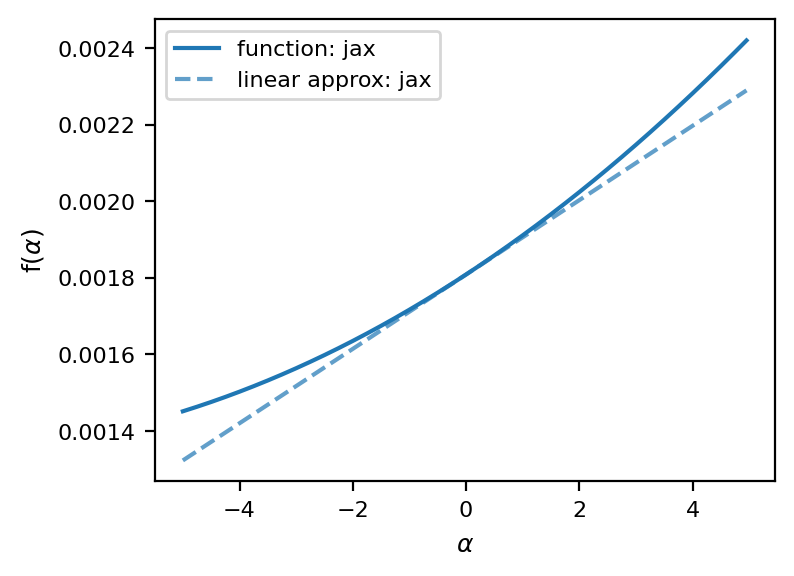

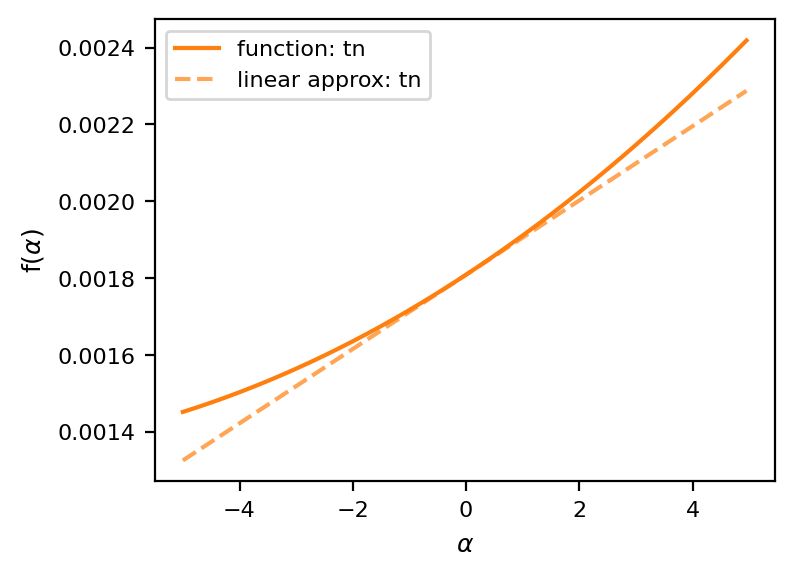

In [632]:

plt.figure(dpi=200, figsize=(4,3))
# Plot function and approximations with matching colors and different line styles
plt.plot(alphas, function_value_povm_jax, color='C0', label='function: jax')           # Solid blue
plt.plot(alphas, linear_approx_povm_jax, '--', color='C0', alpha=0.7, label='linear approx: jax')  # Dashed blue, transparent

plt.xlabel(r'$\alpha$')
plt.ylabel(r'f($\alpha$)')

plt.legend()

plt.figure(dpi=200, figsize=(4,3))

plt.plot(alphas, function_value_povm_numba, color='C1', label='function: tn')       # Solid orange
plt.plot(alphas, linear_approx_povm_numba, '--', color='C1', alpha=0.7, label='linear approx: tn')    # Dashed orange, transparent

plt.xlabel(r'$\alpha$')
plt.ylabel(r'f($\alpha$)')

plt.legend()

In [636]:
are_equal_povm_jax = jnp.array([jnp.allclose(cost, approx, rtol=1e-6) for cost, approx in zip(function_value_povm_jax, linear_approx_povm_jax)])
jnp.where(are_equal_povm_jax)

(Array([100], dtype=int64),)

In [637]:
are_equal_povm_numba = jnp.array([jnp.allclose(cost, approx, rtol=1e-6) for cost, approx in zip(function_value_povm_numba, linear_approx_povm_numba)])
jnp.where(are_equal_povm_numba)

(Array([ 99, 100], dtype=int64),)

In [535]:
alphas = np.arange(-5, 5, 0.05)
function_value_povm_jax = jnp.array(function_value_povm_jax)
numerical_gradients_povm = jnp.gradient(function_value_povm_jax, alphas)
numerical_gradients_povm[100]

Array(8.8193152e-05, dtype=float64)

In [544]:
_gradient = gradient_povm_jax/2
tensor_inner_product_euclidean(_gradient)

Array(4.85967032e-05, dtype=float64)

In [545]:
_gradient = gradient_povm_numba
tensor_inner_product_euclidean(_gradient)

Array(4.83217557e-05, dtype=float64)

In [546]:
_gradient = gradient_povm_numba_no_parallel
tensor_inner_product_euclidean(_gradient)

Array(4.85326098e-05, dtype=float64)

In [547]:
_gradient = gradient_povm_numba_test_no_parallel
tensor_inner_product_euclidean(_gradient)

Array(0.00238046, dtype=float64)

## Kraus gradient

In [599]:
# lets construct the left hand side of the equation
f_k = lambda kraus_tensor: cost_function_jax_mps(kraus=kraus_tensor, povm_psd=povm_psd, state_psd=state_psd, indices_list=indices_list, prob_matrix=prob_matrix, jit=True)
def cost_alpha_kraus(alpha, initial_kraus, jax:bool=True):
    "cost function f(x + alpha*gradient) as a function of alpha"
    if jax:
        gradient = gradient_kraus_jax/2
    else:
        gradient = gradient_kraus_numba
    k_alpha = initial_kraus + alpha * gradient.conj()
    return f_k(k_alpha)

def tensor_inner_product_euclidean_kraus(tensor:jnp.ndarray):
    "Euclidean norm of a tensor of rank 4"
    return jnp.real(jnp.einsum("ijkl,ijkl", tensor, tensor.conj()))

def linear_approx_kraus(alpha, initial_kraus, jax:bool=True):
    "Linear approximation of cost_alpha around k"
    if jax:
        gradient = gradient_kraus_jax/2
    else:
        gradient = gradient_kraus_numba
        
    return f_k(initial_kraus) + 2 * alpha * tensor_inner_product_euclidean_kraus(gradient)

In [600]:
alphas = np.arange(-2, 2, 0.02)
function_value_jax = [cost_alpha_kraus(alpha, kraus_tensor, jax=True) for alpha in alphas]

Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial co

In [601]:
function_value_alpha_tn = [cost_alpha_kraus(alpha, kraus_tensor, jax=False) for alpha in alphas]

Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial co

In [445]:
linear_approx_jax = [linear_approx_kraus(alpha, kraus_tensor, jax=True) for alpha in alphas]
linear_approx_tn = [linear_approx_kraus(alpha, kraus_tensor, jax=False) for alpha in alphas]

Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial count: 30
Initial co

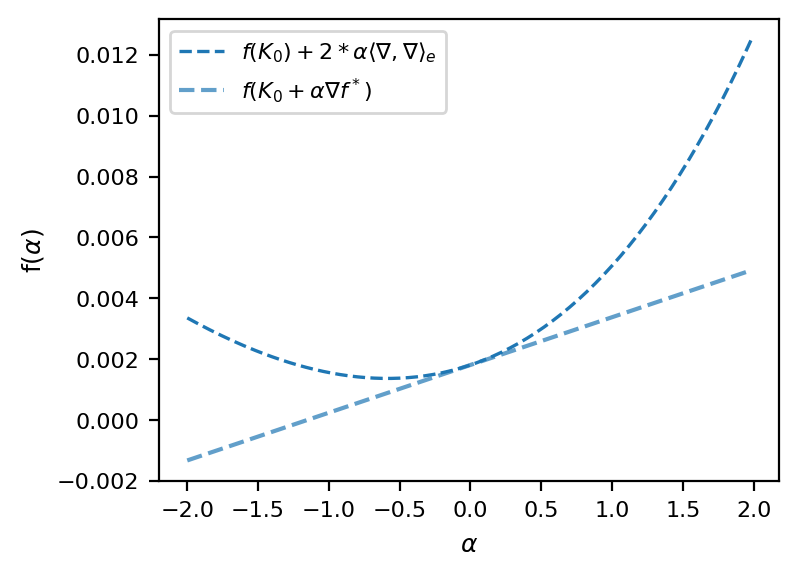

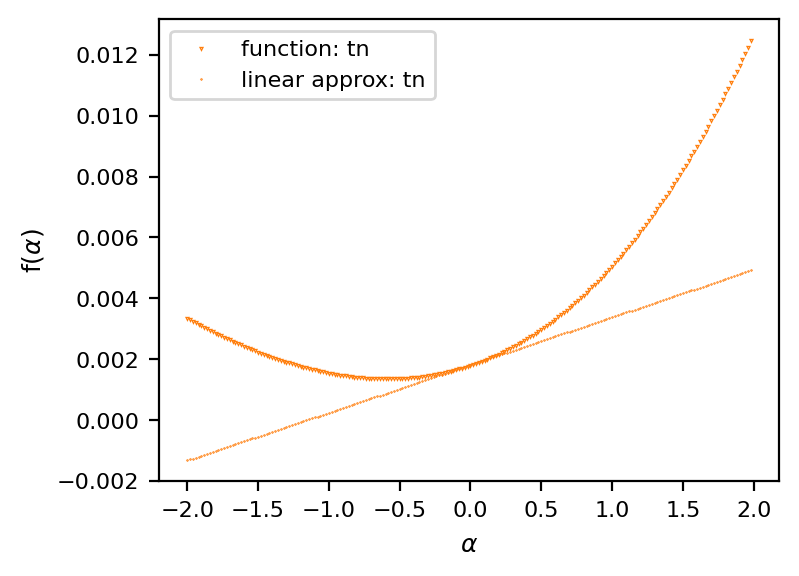

In [617]:

plt.figure(dpi=200, figsize=(4,3))
# Plot function and approximations with matching colors and different line styles
plt.plot(alphas, function_value_jax, '--',color='C0', markersize=0.8, linewidth=1.2, label=r'$f(K_0) + 2 * \alpha \langle \nabla , \nabla \rangle_e$')           # Solid blue
plt.plot(alphas, linear_approx_jax, '--', markersize=0.9, color='C0', alpha=0.7, label=r'$f(K_0 + \alpha \nabla f^* )$')  # Dashed blue, transparent

# plt.title(r'$\nabla = \partial_z f  $')
plt.xlabel(r'$\alpha$')
plt.ylabel(r'f($\alpha$)')

plt.legend()

plt.figure(dpi=200, figsize=(4,3))

plt.plot(alphas, function_value_alpha_tn, 'v', markersize=0.2, color='C1', label='function: tn')       # Solid orange
plt.plot(alphas, linear_approx_tn, '*', markersize=0.3, color='C1', alpha=0.7, label='linear approx: tn')    # Dashed orange, transparent

plt.xlabel(r'$\alpha$')
plt.ylabel(r'f($\alpha$)')

plt.legend()

In [452]:
any(jnp.allclose(cost, approx) for cost, approx in zip(function_value_alpha_tn, linear_approx_tn))

True

In [453]:
are_equal_numba = jnp.array([jnp.allclose(cost, approx, rtol=1e-3) for cost, approx in zip(function_value_alpha_tn, linear_approx_tn)])
jnp.where(are_equal_numba)

(Array([100], dtype=int64),)

In [454]:
are_equal_jax = jnp.array([jnp.allclose(cost, approx, rtol=1e-3) for cost, approx in zip(function_value_jax, linear_approx_jax)])
jnp.where(are_equal_jax)

(Array([100], dtype=int64),)

In [512]:
function_value_jax[100]

Array(0.001809, dtype=float64)

In [550]:
# numerical gradients
alphas = jnp.arange(-2, 2, 0.02)
function_value_jax = jnp.array(function_value_jax)
numerical_gradients_kraus = jnp.gradient(function_value_jax, alphas)
numerical_gradients_kraus[100]

Array(0.00082911, dtype=float64)

In [551]:
# gradient evaluated at the original point
# _gradient = gradient_kraus_numba 
_gradient = gradient_kraus_jax/2
tensor_inner_product_euclidean_kraus(_gradient)

Array(0.00078455, dtype=float64)

In [517]:
eps = 1e-4
# Check b_grad with scalar finite differences
grad_numerical = (f_k(kraus_tensor + _gradient * eps / 2.) - f_k(kraus_tensor - _gradient * eps / 2.)) / eps
grad_numerical

Initial count: 30
Initial count: 30


Array(0.00082909, dtype=float64)

In [573]:
def verify_gradient_using_differential(cost_function:callable, dfdz:jnp.ndarray, initial_point:jnp.ndarray, inner_product:callable, t:float = 1e-6):
    "Verify the validity of a gradient as a first approximation of a real-valued cost function defined on complex inputs"
    LHS = (cost_function(initial_point + t * dfdz.conj()) - cost_function(initial_point))/t
    RHS = 2 * inner_product(dfdz)
    return LHS, RHS
    
dfdz = gradient_kraus_jax/2 
LHS, RHS = verify_gradient_using_differential(f_k, dfdz, kraus_tensor, tensor_inner_product_euclidean_kraus, t=1e-6)

Initial count: 30
Initial count: 30


In [574]:
LHS, RHS, jnp.allclose(LHS, RHS)

(Array(0.0015691, dtype=float64),
 Array(0.0015691, dtype=float64),
 Array(True, dtype=bool))

In [626]:
dfdz = gradient_povm_jax/2 
LHS, RHS = verify_gradient_using_differential(f_povm_jax, dfdz, povm_psd, tensor_inner_product_euclidean, t=1e-6)

Initial count: 30
Initial count: 30


In [627]:
LHS, RHS, jnp.allclose(LHS, RHS)

(Array(9.71934128e-05, dtype=float64),
 Array(9.71934064e-05, dtype=float64),
 Array(True, dtype=bool))

In [583]:
def f_povm_numba_psd(povm_psd): 
    povm_full = np.array([(povm.T.conj() @ povm).reshape(-1) for povm in povm_psd])
    return cost_function_numba(K_np, povm_full, rho_np, J, y_np)

f_povm_numba_psd(A_numba)

0.0018090037849567806

In [642]:
dfdz = gradient_povm_numba_test_no_parallel
initial_point = A_full_rank #A_full_rank.transpose(0, 2, 1)
LHS, RHS = verify_gradient_using_differential(f_povm_numba_psd, dfdz, initial_point, tensor_inner_product_euclidean, t=1e-6)

In [643]:
LHS, RHS, jnp.allclose(LHS, RHS)

(0.00476922394632151,
 Array(0.00476092, dtype=float64),
 Array(False, dtype=bool))

In [578]:
cost_function_jax_mps(kraus_tensor, povm_psd, state_psd, indices_list, prob_matrix, jit=True)

Initial count: 30


Array(0.001809, dtype=float64)

In [580]:
cost_function_numba(K_np, E_np, rho_np, J, y_np)


0.0018090037849567797

# Testing for bug

In [ ]:
from mGST.utility_functions_comparisons import euclidean_gradients_to_stiefel, is_isometry, is_in_tangent_space

gradient_povm_jax_full_rank.shape, povm_psd_full_rank.shape

((4, 4, 4), (4, 4, 4))

In [ ]:
povm_stiefel_gradient, povm_isometry = euclidean_gradients_to_stiefel(gradient_tensor=gradient_povm_jax_full_rank, operator_tensor=povm_psd_full_rank, operator_type="povm")

povm_stiefel_gradient.shape, povm_isometry.shape

((16, 4), (16, 4))

In [33]:
is_isometry(povm_isometry), is_in_tangent_space(povm_isometry, povm_stiefel_gradient)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [ ]:
# Now, we should be able to obtain the original gradient back. Right? I have checked in debug mode
# and we were indeed making a mistake. Now, it should be correct.